In [72]:
import numpy as np
import matplotlib.pyplot as plt
from pysse import ElectricFieldPulse, SSE

In [73]:
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [74]:
intensity = 1E17  # Intensity in W/cm^2
fwhm = 9.4  # FWHM in as
central_frequency = 250  # Pulse oscillation frequency in eV

electric_field_pulse = ElectricFieldPulse(intensity=intensity, dt=5E-3, pulse_type='gaussian', fwhm=fwhm, omega_sin=central_frequency, time_span=8)
#pulse_y = ElectricFieldPulse(intensity=intensity, dt=5E-3, pulse_type='gaussian', fwhm=fwhm, omega_sin=central_frequency, time_span=8)
#pulse_z = ElectricFieldPulse(intensity=intensity, dt=5E-3, pulse_type='gaussian', fwhm=fwhm, omega_sin=central_frequency, time_span=8)

electric_field = {"time": electric_field_pulse.time, "pulse_x": electric_field_pulse.pulse, "pulse_y": np.zeros_like(electric_field_pulse.pulse), "pulse_z": np.zeros_like(electric_field_pulse.pulse)}

In [75]:
print(electric_field_pulse)

Electric Field Pulse:
  Intensity (I): 1e+17 W/cm^2
  FWHM: 9.4 as
  Central frequency: 9.18732590017419 a.u.
  E_max: 1.6878989451394444 a.u.
  Sigma: 0.1650270092543608 a.u.
  Time step (dt): 0.005 a.u.
  Number of steps: 1600
  Pulse type: gaussian
  Time at maximum: 1.0 a.u.
  Energy window: None a.u.
  Pulse width: None a.u.
  


In [76]:
propagation_method = "Heun"

Text(0.5, 1.0, 'FFT of Sinusoidal Gaussian Pulse')

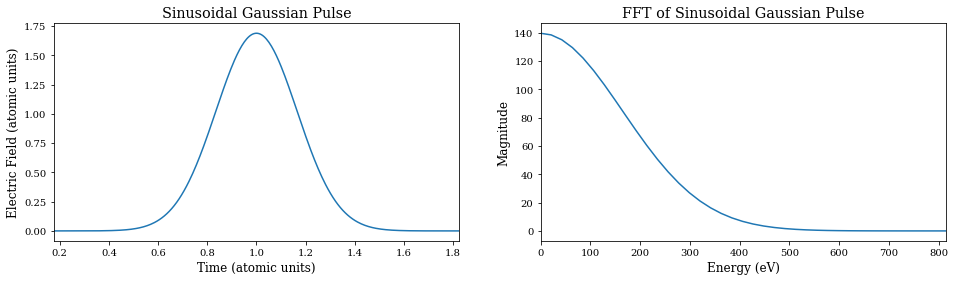

In [77]:
plt.figure(figsize=(16,4))

plt.subplot(1,2,1)
plt.plot(electric_field_pulse.time, electric_field_pulse.pulse, label='Carbon')
plt.xlabel('Time (atomic units)')
plt.ylabel('Electric Field (atomic units)')
plt.xlim(electric_field_pulse.time_limits)
plt.title('Sinusoidal Gaussian Pulse')

plt.subplot(1,2,2)
plt.plot(electric_field_pulse.freq, electric_field_pulse.magnitude)
plt.xlim(electric_field_pulse.freq_limits)
plt.xlabel('Energy (eV)')
plt.ylabel('Magnitude')
plt.title('FFT of Sinusoidal Gaussian Pulse')

In [78]:
gamma = np.array([
    [1,2,2]
]) # [final state, initial state, gamma]

In [79]:
initial_conditions = np.array([
    [0,0.9],
    [2,0.1]
])

In [80]:
import os
print(os.cpu_count())

64


In [81]:
n_paths = 3
n_jobs = 10
random_seed = None #Candidates: 10, 14, 16, 24, 2008

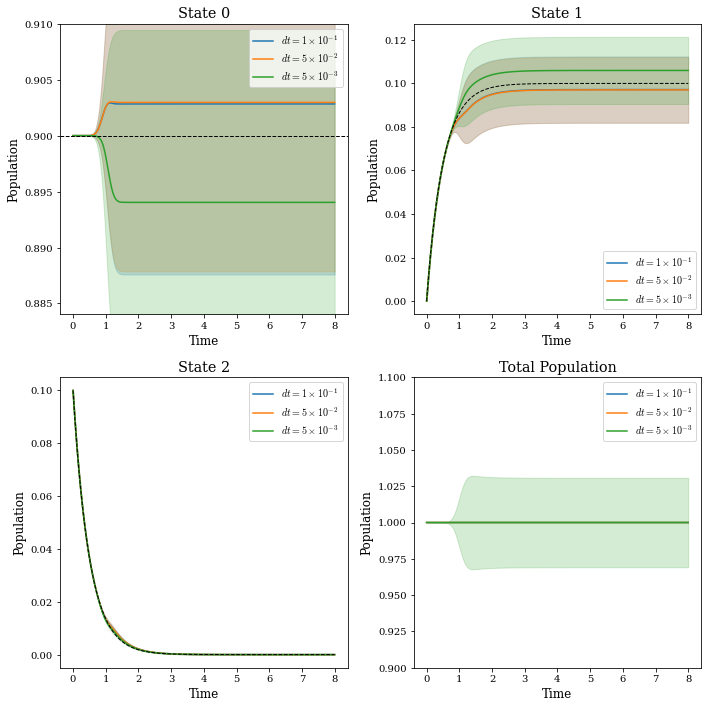

In [82]:
#dt_values = [1E-1, 5E-2, 5E-3, 5E-4]
#colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

dt_values = [1E-1, 5E-2, 5E-3]
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for dt, color in zip(dt_values, colors):
    electric_field_pulse = ElectricFieldPulse(intensity=intensity, dt=5E-3, pulse_type='gaussian', fwhm=fwhm, omega_sin=central_frequency, time_span=8)
    #pulse_y = ElectricFieldPulse(intensity=intensity, dt=dt, pulse_type='gaussian_sin', fwhm=fwhm, omega_sin=central_frequency, time_span=8)
    #pulse_z = ElectricFieldPulse(intensity=intensity, dt=dt, pulse_type='gaussian_sin', fwhm=fwhm, omega_sin=central_frequency, time_span=8)

    electric_field = {"time": electric_field_pulse.time, "pulse_x": electric_field_pulse.pulse, "pulse_y": np.zeros_like(electric_field_pulse.pulse), "pulse_z": np.zeros_like(electric_field_pulse.pulse)}
    sse = SSE("/home/sanchez/Trieste_Project/Chemistry/Scripts/SSE/dummy_data/", electric_field, gamma, initial_conditions, n_paths, propagation_method, n_jobs, random_seed)

    pop0 = sse.population_average[:, 0]
    pop1 = sse.population_average[:, 1]
    pop2 = sse.population_average[:, 2]
    pop0_std = sse.population_std[:, 0]
    pop1_std = sse.population_std[:, 1]
    pop2_std = sse.population_std[:, 2]
    total_population = pop0 + pop1 + pop2
    total_population_std = pop0_std + pop1_std + pop2_std

    mantissa_str, exponent_str = f"{dt:.1e}".split('e')
    mantissa = float(mantissa_str)
    exponent = int(exponent_str)
    label_dt = rf'$dt = {mantissa:g}\times10^{{{exponent}}}$'
    axes[0,0].plot(sse.time, pop0, label=label_dt, color=color)
    axes[0,0].fill_between(sse.time, pop0 - pop0_std, pop0 + pop0_std, color=color, alpha=0.2)

    axes[0,1].plot(sse.time, pop1, label=label_dt, color=color)
    axes[0,1].fill_between(sse.time, pop1 - pop1_std, pop1 + pop1_std, color=color, alpha=0.2)

    axes[1,0].plot(sse.time, pop2, label=label_dt, color=color)
    axes[1,0].fill_between(sse.time, pop2 - pop2_std, pop2 + pop2_std, color=color, alpha=0.2)

    axes[1,1].plot(sse.time, total_population, label=label_dt, color=color)


pop0_theo = 0.9
pop1_theo = 1 - 0.9 - 0.1*np.exp(-(gamma[0,2])*sse.time)
pop2_theo = 0.1*np.exp(-(gamma[0,2])*sse.time)


axes[0,0].axhline(initial_conditions[0,1], color='black', linestyle='--', linewidth=1)
#axes[0,0].plot(sse.time, pop0_theo, color='black', linestyle='--', linewidth=1)
axes[0,0].set_title('State 0')
axes[0,0].set_xlabel('Time')
axes[0,0].set_ylabel('Population')
#axes[0,0].set_xlim(-0.3, 5)
axes[0,0].set_ylim(pop0.min()-1E-2, pop0.max()+1E-2)
axes[0,0].legend()

#axes[0,1].axhline(initial_conditions[1,1], color='black', linestyle='--', linewidth=1)
axes[0,1].plot(sse.time, pop1_theo, color='black', linestyle='--', linewidth=1)
axes[0,1].set_title('State 1')
axes[0,1].set_xlabel('Time')
axes[0,1].set_ylabel('Population')
#axes[0,1].set_xlim(-0.3, 5)
axes[0,1].legend()

axes[1,0].plot(sse.time, pop2_theo, color='black', linestyle='--', linewidth=1)
axes[1,0].set_title('State 2')
axes[1,0].set_xlabel('Time')
axes[1,0].set_ylabel('Population')
#axes[1,0].set_xlim(-0.3, 5)
axes[1,0].legend()

axes[1,1].set_title('Total Population')
axes[1,1].fill_between(sse.time, total_population - total_population_std, total_population + total_population_std, color=color, alpha=0.2)
axes[1,1].set_xlabel('Time')
axes[1,1].set_ylabel('Population')
#axes[1,1].set_xlim(-0.3, 5)
axes[1,1].set_ylim(0.9, 1.1)
axes[1,1].legend()

plt.tight_layout()
plt.show()

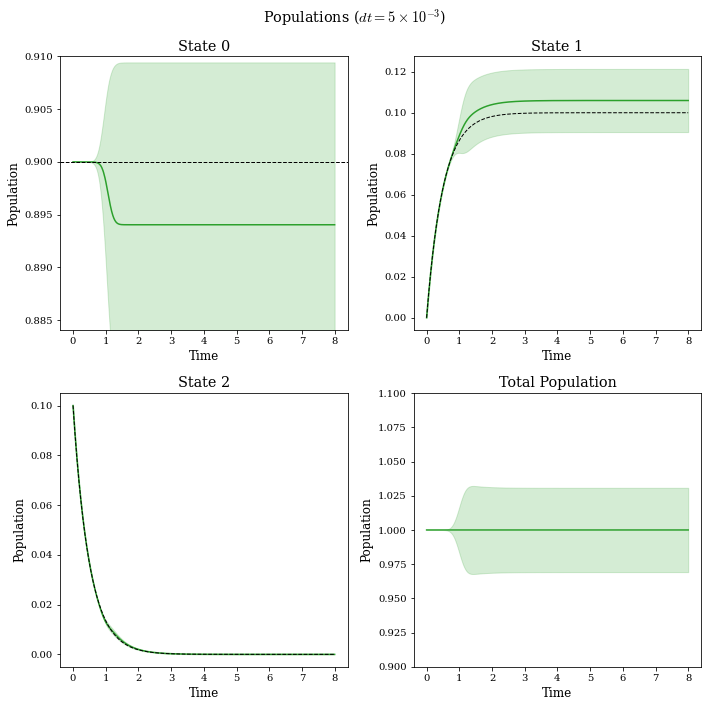

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0,0].plot(sse.time, pop0, color=color)
axes[0,0].axhline(initial_conditions[0,1], color='black', linestyle='--', linewidth=1)
#axes[0,0].plot(sse.time, pop0_theo, color='black', linestyle='--', linewidth=1)
axes[0,0].fill_between(sse.time, pop0 - pop0_std, pop0 + pop0_std, color=color, alpha=0.2)
axes[0,0].set_title('State 0')
axes[0,0].set_xlabel('Time')
axes[0,0].set_ylabel('Population')
#axes[0,0].set_xlim(-0.3, 5)
axes[0,0].set_ylim(pop0.min()-1E-2, pop0.max()+1E-2)

#axes[0,1].axhline(initial_conditions[1,1], color='black', linestyle='--', linewidth=1)
axes[0,1].plot(sse.time, pop1, color=color)
axes[0,1].plot(sse.time, pop1_theo, color='black', linestyle='--', linewidth=1)
axes[0,1].fill_between(sse.time, pop1 - pop1_std, pop1 + pop1_std, color=color, alpha=0.2)
axes[0,1].set_title('State 1')
axes[0,1].set_xlabel('Time')
axes[0,1].set_ylabel('Population')
#axes[0,1].set_xlim(-0.3, 5)

axes[1,0].plot(sse.time, pop2, color=color)
axes[1,0].fill_between(sse.time, pop2 - pop2_std, pop2 + pop2_std, color=color, alpha=0.2)
axes[1,0].plot(sse.time, pop2_theo, color='black', linestyle='--', linewidth=1)
axes[1,0].set_title('State 2')
axes[1,0].set_xlabel('Time')
axes[1,0].set_ylabel('Population')
#axes[1,0].set_xlim(-0.3, 5)

axes[1,1].plot(sse.time, total_population, color=color)
axes[1,1].fill_between(sse.time, total_population - total_population_std, total_population + total_population_std, color=color, alpha=0.2)
axes[1,1].set_title('Total Population')
axes[1,1].set_xlabel('Time')
axes[1,1].set_ylabel('Population')
#axes[1,1].set_xlim(-0.3, 5)
axes[1,1].set_ylim(0.90, 1.1)

fig.suptitle("Populations (" + label_dt + ")")

plt.tight_layout()
plt.show()

In [88]:
# --- c_t_1.dat ... c_t_28.dat: |C_j|^2 por archivo y suma entre archivos ---
import os

base_dir = "/home/sanchez/test_sse/third_test/EuMar"
pop_sum = None
pop_sum_sq = None
t = None
ncoeff = None
n_paths = 30

for i in range(1, n_paths+1):
    input_path = os.path.join(base_dir, "c_t_{}.dat".format(i))
    if not os.path.isfile(input_path):
        raise FileNotFoundError("No existe: {}".format(input_path))

    data = np.genfromtxt(input_path, comments="#")
    data = np.atleast_2d(data)
    # Columnas: istep, time, Re(C0), Im(C0), ...

    t_i = data[:, 1]
    reim = data[:, 2:]

    if reim.shape[1] % 2 != 0:
        raise ValueError(
            "{}: columnas Re/Im sin pares. columnas_after_time={}".format(
                input_path, reim.shape[1]
            )
        )

    re = reim[:, 0::2]
    im = reim[:, 1::2]
    pop_i = re ** 2 + im ** 2

    if pop_sum is None:
        t = np.asarray(t_i, dtype=float)
        pop_sum = pop_i.astype(float, copy=True)
        pop_sum_sq = pop_i ** 2
        ncoeff = pop_i.shape[1]
    else:
        if pop_i.shape != pop_sum.shape:
            raise ValueError(
                "{}: forma {} distinta de la referencia {}".format(
                    input_path, pop_i.shape, pop_sum.shape
                )
            )
        if not np.allclose(t_i, t, rtol=0, atol=1e-9):
            raise ValueError(
                "{}: columna time no coincide con el primer archivo".format(input_path)
            )
        pop_sum += pop_i
        pop_sum_sq += pop_i ** 2

pop = pop_sum/n_paths
variance = (pop_sum_sq - pop_sum ** 2 / n_paths) / (n_paths - 1)
pop_std = np.sqrt(np.abs(variance))

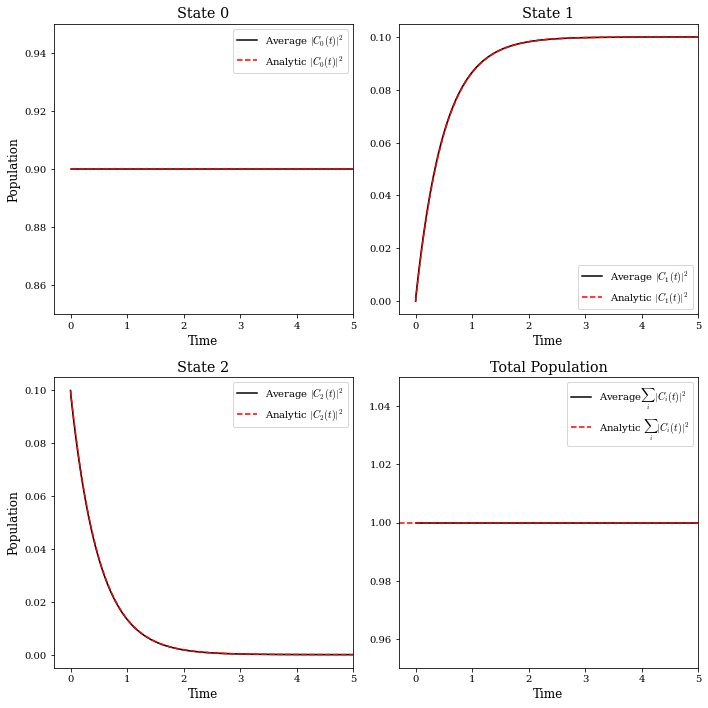

In [89]:
pop0_dat = pop[:, 0]
pop1_dat = pop[:, 1]
pop2_dat = pop[:, 2]
total_dat = pop.sum(axis=1)

pop0_std = pop_std[:, 0]
pop1_std = pop_std[:, 1]
pop2_std = pop_std[:, 2]
total_std = pop_std.sum(axis=1)

p_0_0 = 0.9
p_1_0 = 0.0
p_2_0 = 0.1
p_0_th = p_0_0*np.ones_like(t)
p_1_th = 1 - p_0_0 - p_2_0*np.exp(-(gamma[0,2])*t)
p_2_th = 1 - p_0_th - p_1_th

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Left subplot: |C_average[:,1]|^2 vs Analytic
axes[0,0].plot(t, pop0_dat, label=r'Average $|C_0(t)|^2$', color='black')
axes[0,0].fill_between(t, pop0_dat - pop0_std, pop0_dat + pop0_std, color='black', alpha=0.2)
axes[0,0].plot(t, p_0_th, label=r'Analytic $|C_0(t)|^2$', color='red', linestyle='--')
axes[0,0].set_title('State 0')
axes[0,0].set_xlabel('Time')
axes[0,0].set_ylabel('Population')
axes[0,0].set_xlim(-0.3, 5)
axes[0,0].set_ylim(0.85, 0.95)
axes[0,0].legend()

# Middle subplot: |C_average[:,0]|^2 vs Analytic
axes[0,1].plot(t, pop1_dat, label=r'Average $|C_1(t)|^2$', color='black')
axes[0,1].fill_between(t, pop1_dat - pop1_std, pop1_dat + pop1_std, color='black', alpha=0.2)
axes[0,1].plot(t, p_1_th, label=r'Analytic $|C_1(t)|^2$', color='red', linestyle='--')
axes[0,1].set_title('State 1')
axes[0,1].set_xlabel('Time')
#axes[1].set_ylabel('Population')
axes[0,1].set_xlim(-0.3, 5)
axes[0,1].legend()

axes[1,0].plot(t, pop2_dat, label=r'Average $|C_2(t)|^2$', color='black')
axes[1,0].fill_between(t, pop2_dat - pop2_std, pop2_dat + pop2_std, color='black', alpha=0.2)
axes[1,0].plot(t, p_2_th, label=r'Analytic $|C_2(t)|^2$', color='red', linestyle='--')
axes[1,0].set_title('State 2')
axes[1,0].set_xlabel('Time')
axes[1,0].set_ylabel('Population')
axes[1,0].set_xlim(-0.3, 5)
axes[1,0].legend()

# Right subplot: total population
axes[1,1].plot(t, total_dat, label=r'Average$\sum_i |C_i(t)|^2$', color='black')
axes[1,1].fill_between(t, total_dat - total_std, total_dat + total_std, color='black', alpha=0.2)
axes[1,1].axhline(1, color='red', linestyle='--', label=r'Analytic $\sum_i |C_i(t)|^2$')
axes[1,1].set_title('Total Population')
axes[1,1].set_xlabel('Time')
#axes[2].set_ylabel('Population')
axes[1,1].set_xlim(-0.3, 5)
axes[1,1].set_ylim(0.95, 1.05)
axes[1,1].legend()

plt.tight_layout()
plt.show()

